In [1]:
## XGBoost vs. linear-lag-dummy regression: does a nonlinear model improve the demand forecast?
#
# Same point-forecast target (ND) and identical input features as forecast.py's linear model
# (y_lag_1, y_lag_48, y_lag_336 + one-hot settlement-period dummies) -- isolates the model
# change from any feature change.
#
# 1. Primary single split (same split_date as forecast_with_interval) -- direct comparison
#    to the already-reported linear model numbers (MAE 429)
# 2. Walk-forward validation: 6 expanding-window folds, calendar-month test blocks Jul-Dec,
#    training >=~6 months, early-stopping validation carved from the last month of each
#    fold's own training window (never the test block)
# 3. Metrics: MAE, RMSE, by-hour breakdown, per-window Diebold-Mariano significance test
# 4. (End of notebook) dispatch impact -- only pursued if the metrics above show a real
#    improvement

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from xgboost import XGBRegressor

from energy_forecast.data import load_demand_data
from energy_forecast.features import build_features
from energy_forecast.forecast import _fit_mean_model

g++ not available, if using conda: `conda install gxx`


In [3]:
raw = load_demand_data("../data/demanddata_2024.csv")
df = build_features(raw)

# Identical feature set to _fit_mean_model (forecast.py:21) -- the whole point of the
# primary comparison is holding input information fixed and changing only the model.
feature_cols = ['y_lag_1', 'y_lag_48', 'y_lag_336'] + [c for c in df.columns if c.startswith('period')]

print(f"rows: {len(df)}, features: {len(feature_cols)}")
print(f"date range: {df.index.min()} -> {df.index.max()}")

rows: 17232, features: 52
date range: 2024-01-08 00:00:00+00:00 -> 2024-12-31 23:30:00+00:00


In [4]:
## Hyperparameters (agreed): defaults except learning_rate and n_estimators, which are
## paired with early stopping rather than used as fixed values; no tuning pass this round.

XGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=0,
    early_stopping_rounds=50,
)


def fit_xgboost_forecast(df, split_date, feature_cols, valid_months=1, xgb_params=XGB_PARAMS):
    """Fit XGBoost with early stopping. The last `valid_months` of the training window
    (chronologically before split_date) is carved out as the early-stopping validation
    slice -- never used to fit a tree split, and distinct from the test block (>= split_date),
    which this function does not touch until the final .predict call."""
    train_df = df[df.index < split_date]
    test_df = df[df.index >= split_date]

    fit_cutoff = train_df.index.max() - pd.DateOffset(months=valid_months)
    fit_df = train_df[train_df.index < fit_cutoff]
    valid_df = train_df[train_df.index >= fit_cutoff]

    X_fit, y_fit = fit_df[feature_cols], fit_df['ND']
    X_valid, y_valid = valid_df[feature_cols], valid_df['ND']
    X_test = test_df[feature_cols]

    model = XGBRegressor(**xgb_params)
    model.fit(X_fit, y_fit, eval_set=[(X_valid, y_valid)], verbose=False)

    y_fore = pd.Series(model.predict(X_test), index=X_test.index)

    return train_df, test_df, y_fore, model


def mae(actual, forecast):
    return float(np.mean(np.abs(actual - forecast)))


def rmse(actual, forecast):
    return float(np.sqrt(np.mean((actual - forecast) ** 2)))

In [5]:
## 1. Primary split: same split_date as the existing linear model

n = len(df)
split_date = df.index[int(n * 0.8)]

train_df, test_df, y_pred_train, y_fore_linear = _fit_mean_model(df, split_date)
_, _, y_fore_xgb, xgb_model = fit_xgboost_forecast(df, split_date, feature_cols)

actual = test_df['ND']

print(f"split_date: {split_date}")
print(f"train rows: {len(train_df)}, test rows: {len(test_df)}")
print(f"xgboost best_iteration: {xgb_model.best_iteration}")
print()
print(f"Linear  -- MAE: {mae(actual, y_fore_linear):.1f}, RMSE: {rmse(actual, y_fore_linear):.1f}")
print(f"XGBoost -- MAE: {mae(actual, y_fore_xgb):.1f}, RMSE: {rmse(actual, y_fore_xgb):.1f}")

split_date: 2024-10-21 04:30:00+00:00
train rows: 13785, test rows: 3447
xgboost best_iteration: 482

Linear  -- MAE: 420.4, RMSE: 533.3
XGBoost -- MAE: 343.5, RMSE: 453.2


In [6]:
## 1b. By-hour breakdown, primary split

local_hour = actual.index.tz_convert("Europe/London").hour
by_hour = pd.DataFrame({
    "linear_mae": (actual - y_fore_linear).abs().groupby(local_hour).mean(),
    "xgboost_mae": (actual - y_fore_xgb).abs().groupby(local_hour).mean(),
})
by_hour["xgboost_minus_linear"] = by_hour["xgboost_mae"] - by_hour["linear_mae"]
by_hour

,linear_mae,xgboost_mae,xgboost_minus_linear
datetime,,,
0,399.889838,208.525858,-191.363979
1,248.885427,233.451972,-15.433455
2,168.868588,184.148905,15.280317
3,152.402919,162.035211,9.632292
4,187.000773,174.903994,-12.096778
5,386.548927,330.839530,-55.709397
6,839.913832,459.138713,-380.775120
7,669.560343,386.492364,-283.067979
8,539.438248,476.056288,-63.381960


In [7]:
## 2. Walk-forward validation: 6 expanding-window folds, calendar-month test blocks
## (train always starts at data_start; only the train length and test month change per fold)

data_start = df.index.min()
fold_boundaries = pd.date_range("2024-07-01", periods=7, freq="MS", tz=data_start.tz)

folds = [
    {"fold": i + 1, "train_start": data_start, "test_start": fold_boundaries[i], "test_end": fold_boundaries[i + 1]}
    for i in range(6)
]

pd.DataFrame(folds)

,fold,train_start,test_start,test_end
0,1,2024-01-08 00:00:00+00:00,2024-07-01 00:00:00+00:00,2024-08-01 00:00:00+00:00
1,2,2024-01-08 00:00:00+00:00,2024-08-01 00:00:00+00:00,2024-09-01 00:00:00+00:00
2,3,2024-01-08 00:00:00+00:00,2024-09-01 00:00:00+00:00,2024-10-01 00:00:00+00:00
3,4,2024-01-08 00:00:00+00:00,2024-10-01 00:00:00+00:00,2024-11-01 00:00:00+00:00
4,5,2024-01-08 00:00:00+00:00,2024-11-01 00:00:00+00:00,2024-12-01 00:00:00+00:00
5,6,2024-01-08 00:00:00+00:00,2024-12-01 00:00:00+00:00,2025-01-01 00:00:00+00:00


In [8]:
## 2b. Fit both models on each fold, collect metrics
## Both models are refit per fold at that fold's own test_start, so the comparison within
## each fold is a fair paired one (identical train/test rows for both models).

fold_results = []
fold_predictions = {}

for f in folds:
    split_date_f = f["test_start"]

    train_df_f, test_df_f, y_pred_train_f, y_fore_linear_f = _fit_mean_model(df, split_date_f)
    _, _, y_fore_xgb_f, xgb_model_f = fit_xgboost_forecast(df, split_date_f, feature_cols)

    # _fit_mean_model's test_df runs to the end of df; restrict to this fold's test window
    test_mask = test_df_f.index < f["test_end"]
    actual_f = test_df_f.loc[test_mask, 'ND']
    y_fore_linear_f = y_fore_linear_f.loc[test_mask]
    y_fore_xgb_f = y_fore_xgb_f.loc[test_mask]

    fold_results.append({
        "fold": f["fold"],
        "test_start": f["test_start"],
        "test_end": f["test_end"],
        "n_train": len(train_df_f),
        "n_test": len(actual_f),
        "xgb_best_iteration": xgb_model_f.best_iteration,
        "linear_mae": mae(actual_f, y_fore_linear_f),
        "xgboost_mae": mae(actual_f, y_fore_xgb_f),
        "linear_rmse": rmse(actual_f, y_fore_linear_f),
        "xgboost_rmse": rmse(actual_f, y_fore_xgb_f),
    })

    fold_predictions[f["fold"]] = {
        "actual": actual_f,
        "linear": y_fore_linear_f,
        "xgboost": y_fore_xgb_f,
    }

fold_results_df = pd.DataFrame(fold_results)
fold_results_df

,fold,test_start,test_end,n_train,n_test,xgb_best_iteration,linear_mae,xgboost_mae,linear_rmse,xgboost_rmse
0,1,2024-07-01 00:00:00+00:00,2024-08-01 00:00:00+00:00,8400,1488,313,289.221869,251.143866,394.988176,330.697814
1,2,2024-08-01 00:00:00+00:00,2024-09-01 00:00:00+00:00,9888,1488,226,280.513997,262.473839,376.933048,343.661086
2,3,2024-09-01 00:00:00+00:00,2024-10-01 00:00:00+00:00,11376,1440,529,292.352720,308.963364,382.578766,410.101223
3,4,2024-10-01 00:00:00+00:00,2024-11-01 00:00:00+00:00,12816,1488,418,334.450318,332.399611,430.223175,429.455281
4,5,2024-11-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,14304,1440,498,421.120918,329.496110,530.024049,426.344773
5,6,2024-12-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,15744,1488,395,426.823371,369.609575,541.249236,493.273071


In [9]:
## 2c. By-hour breakdown, pooled across all 6 walk-forward test blocks (Jul-Dec combined)

all_actual = pd.concat([fold_predictions[f]["actual"] for f in fold_predictions])
all_linear = pd.concat([fold_predictions[f]["linear"] for f in fold_predictions])
all_xgb = pd.concat([fold_predictions[f]["xgboost"] for f in fold_predictions])

pooled_local_hour = all_actual.index.tz_convert("Europe/London").hour
pooled_by_hour = pd.DataFrame({
    "linear_mae": (all_actual - all_linear).abs().groupby(pooled_local_hour).mean(),
    "xgboost_mae": (all_actual - all_xgb).abs().groupby(pooled_local_hour).mean(),
})
pooled_by_hour["xgboost_minus_linear"] = pooled_by_hour["xgboost_mae"] - pooled_by_hour["linear_mae"]
pooled_by_hour

,linear_mae,xgboost_mae,xgboost_minus_linear
datetime,,,
0,304.232326,227.172499,-77.059826
1,190.574139,196.786740,6.212601
2,140.028995,161.518661,21.489666
3,151.675260,159.369841,7.694581
4,145.194856,157.159880,11.965024
5,314.720855,293.550911,-21.169944
6,685.934453,432.714233,-253.220219
7,551.202510,388.987132,-162.215377
8,412.400139,422.074235,9.674096


In [10]:
## 3. Diebold-Mariano test: is either model's error significantly lower, per window?
#
# d_t = loss(linear error at t) - loss(xgboost error at t); positive mean(d) => xgboost better.
# Uses squared error as the loss (matches RMSE / the XGBoost training objective). Half-hourly
# forecast errors are autocorrelated, not iid, so a plain paired t-test on d_t would understate
# uncertainty; this uses a Newey-West long-run variance estimate instead, with the Harvey-
# Leybourne-Newbold (1997) small-sample correction (fold sizes here are ~1300-1500 rows, not
# asymptotic).

def diebold_mariano(actual, forecast_a, forecast_b, h=1, loss="squared"):
    """DM test comparing forecast_a vs forecast_b. Returns (dm_stat, p_value).
    Positive dm_stat means forecast_a has higher loss than forecast_b (b is better)."""
    e_a = actual - forecast_a
    e_b = actual - forecast_b

    if loss == "squared":
        d = e_a**2 - e_b**2
    elif loss == "absolute":
        d = e_a.abs() - e_b.abs()
    else:
        raise ValueError(f"unknown loss: {loss}")

    d = d.to_numpy()
    t = len(d)
    d_mean = d.mean()

    # Newey-West long-run variance, lag truncation h-1 (h = forecast horizon in steps)
    gamma_0 = np.sum((d - d_mean) ** 2) / t
    var_d = gamma_0
    for lag in range(1, h):
        gamma_lag = np.sum((d[lag:] - d_mean) * (d[:-lag] - d_mean)) / t
        var_d += 2 * gamma_lag
    var_d /= t

    dm_stat = d_mean / np.sqrt(var_d)

    # Harvey, Leybourne, Newbold (1997) small-sample correction
    correction = np.sqrt((t + 1 - 2 * h + h * (h - 1) / t) / t)
    dm_stat_corrected = dm_stat * correction

    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat_corrected), df=t - 1))

    return dm_stat_corrected, p_value

In [11]:
## 3b. Apply DM test to the primary split and each of the 6 walk-forward folds

dm_results = []

dm_stat, p_value = diebold_mariano(actual, y_fore_linear, y_fore_xgb, h=1, loss="squared")
dm_results.append({
    "window": "primary", "test_start": split_date, "test_end": df.index.max(),
    "dm_stat": dm_stat, "p_value": p_value,
})

for f in folds:
    preds = fold_predictions[f["fold"]]
    dm_stat, p_value = diebold_mariano(preds["actual"], preds["linear"], preds["xgboost"], h=1, loss="squared")
    dm_results.append({
        "window": f"fold_{f['fold']}", "test_start": f["test_start"], "test_end": f["test_end"],
        "dm_stat": dm_stat, "p_value": p_value,
    })

pd.DataFrame(dm_results)

,window,test_start,test_end,dm_stat,p_value
0,primary,2024-10-21 04:30:00+00:00,2024-12-31 23:30:00+00:00,13.455789,0.000000e+00
1,fold_1,2024-07-01 00:00:00+00:00,2024-08-01 00:00:00+00:00,5.574998,2.935154e-08
2,fold_2,2024-08-01 00:00:00+00:00,2024-09-01 00:00:00+00:00,3.236647,1.236064e-03
3,fold_3,2024-09-01 00:00:00+00:00,2024-10-01 00:00:00+00:00,-3.513395,4.561168e-04
4,fold_4,2024-10-01 00:00:00+00:00,2024-11-01 00:00:00+00:00,0.109621,9.127247e-01
5,fold_5,2024-11-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,11.287700,0.000000e+00
6,fold_6,2024-12-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,4.663314,3.390594e-06


In [12]:
## 5. Peak-hour mechanism check: does an explicit period x lag_1 interaction term in the
## linear model close most of XGBoost's peak-hour advantage?
#
# The plain linear model has one fixed y_lag_1 coefficient across all 48 periods -- it can't
# represent "recent momentum predicts differently depending on time of day". XGBoost can, by
# splitting on period and lag value in the same tree. This adds that one specific interaction
# to linear regression (a separate y_lag_1 slope per period, via period_p * y_lag_1 terms) as
# a direct, controlled test of whether that's the mechanism. Primary split, for direct
# comparison to the by-hour table in section 1b.

from sklearn.linear_model import LinearRegression

period_cols = [c for c in df.columns if c.startswith('period')]

def add_lag1_interactions(df, period_cols):
    df = df.copy()
    interaction_cols = []
    for p in period_cols:
        col = f"{p}_x_lag1"
        df[col] = df[p].astype(float) * df['y_lag_1']
        interaction_cols.append(col)
    return df, interaction_cols

df_interact, interaction_cols = add_lag1_interactions(df, period_cols)
interaction_feature_cols = feature_cols + interaction_cols

train_df_i = df_interact[df_interact.index < split_date]
test_df_i = df_interact[df_interact.index >= split_date]

interact_model = LinearRegression(fit_intercept=True)
interact_model.fit(train_df_i[interaction_feature_cols], train_df_i['ND'])
y_fore_interact = pd.Series(interact_model.predict(test_df_i[interaction_feature_cols]), index=test_df_i.index)

print(f"Linear             -- MAE: {mae(actual, y_fore_linear):.1f}, RMSE: {rmse(actual, y_fore_linear):.1f}")
print(f"Linear + interact  -- MAE: {mae(actual, y_fore_interact):.1f}, RMSE: {rmse(actual, y_fore_interact):.1f}")
print(f"XGBoost            -- MAE: {mae(actual, y_fore_xgb):.1f}, RMSE: {rmse(actual, y_fore_xgb):.1f}")

Linear             -- MAE: 420.4, RMSE: 533.3
Linear + interact  -- MAE: 319.8, RMSE: 419.3
XGBoost            -- MAE: 343.5, RMSE: 453.2


In [13]:
## 5b. By-hour comparison: linear vs. linear+interaction vs. XGBoost, primary split

by_hour_interact = pd.DataFrame({
    "linear_mae": (actual - y_fore_linear).abs().groupby(local_hour).mean(),
    "linear_interact_mae": (actual - y_fore_interact).abs().groupby(local_hour).mean(),
    "xgboost_mae": (actual - y_fore_xgb).abs().groupby(local_hour).mean(),
})
by_hour_interact

,linear_mae,linear_interact_mae,xgboost_mae
datetime,,,
0,399.889838,318.389869,208.525858
1,248.885427,221.010815,233.451972
2,168.868588,164.172143,184.148905
3,152.402919,146.855926,162.035211
4,187.000773,169.217618,174.903994
5,386.548927,324.036007,330.839530
6,839.913832,459.347543,459.138713
7,669.560343,317.290339,386.492364
8,539.438248,480.395788,476.056288


In [14]:
## 6. September by-hour breakdown (fold 3 specifically, not pooled)

def fold_by_hour(fold_id):
    preds = fold_predictions[fold_id]
    hour = preds["actual"].index.tz_convert("Europe/London").hour
    out = pd.DataFrame({
        "linear_mae": (preds["actual"] - preds["linear"]).abs().groupby(hour).mean(),
        "xgboost_mae": (preds["actual"] - preds["xgboost"]).abs().groupby(hour).mean(),
    })
    out["xgboost_minus_linear"] = out["xgboost_mae"] - out["linear_mae"]
    return out

september_by_hour = fold_by_hour(3)
september_by_hour

,linear_mae,xgboost_mae,xgboost_minus_linear
datetime,,,
0,196.558150,204.433919,7.875769
1,132.016020,124.984440,-7.031580
2,126.439319,133.410872,6.971553
3,131.089522,134.163167,3.073645
4,134.133744,170.746159,36.612415
5,283.078734,334.952393,51.873658
6,598.529948,517.775814,-80.754134
7,448.317525,370.657161,-77.660364
8,413.008048,470.505957,57.497909


In [15]:
## 6b. October by-hour breakdown (fold 4 specifically, not pooled)

october_by_hour = fold_by_hour(4)
october_by_hour

,linear_mae,xgboost_mae,xgboost_minus_linear
datetime,,,
0,199.419557,203.367676,3.948119
1,252.432565,240.205505,-12.227059
2,148.117020,177.256143,29.139123
3,154.114676,176.225932,22.111256
4,143.353033,150.551537,7.198505
5,338.695846,293.441154,-45.254692
6,712.221037,533.831811,-178.389226
7,599.429828,428.047253,-171.382575
8,417.786589,438.877898,21.091309


In [16]:
## 7. Train vs. test MAE per fold, XGBoost -- overfitting check
# A widening gap (low train MAE, not-correspondingly-low test MAE) specifically in fold 3
# (September, one of the shorter-training folds) would be the signature of overfitting,
# distinct from the extrapolation and "less signal" explanations checked elsewhere here.

train_test_gap = []
for f in folds:
    split_date_f = f["test_start"]
    train_df_f, test_df_f, y_fore_xgb_f, xgb_model_f = fit_xgboost_forecast(df, split_date_f, feature_cols)
    y_pred_train_f = pd.Series(xgb_model_f.predict(train_df_f[feature_cols]), index=train_df_f.index)

    test_mask = test_df_f.index < f["test_end"]
    train_test_gap.append({
        "fold": f["fold"],
        "n_train": len(train_df_f),
        "xgb_train_mae": mae(train_df_f['ND'], y_pred_train_f),
        "xgb_test_mae": mae(test_df_f.loc[test_mask, 'ND'], y_fore_xgb_f.loc[test_mask]),
    })

train_test_gap_df = pd.DataFrame(train_test_gap)
train_test_gap_df["test_minus_train_gap"] = train_test_gap_df["xgb_test_mae"] - train_test_gap_df["xgb_train_mae"]
train_test_gap_df

,fold,n_train,xgb_train_mae,xgb_test_mae,test_minus_train_gap
0,1,8400,190.545382,251.143866,60.598484
1,2,9888,201.571535,262.473839,60.902304
2,3,11376,164.429939,308.963364,144.533425
3,4,12816,186.769576,332.399611,145.630035
4,5,14304,184.369583,329.496110,145.126527
5,6,15744,202.849194,369.609575,166.760381


In [17]:
## 8. Extrapolation check, September fold (fold 3) -- do test-period values fall outside
## the range XGBoost's trees actually saw during that fold's training?

fold_3 = folds[2]
train_df_3, test_df_3, _, _ = _fit_mean_model(df, fold_3["test_start"])
test_df_3 = test_df_3[test_df_3.index < fold_3["test_end"]]

check_cols = ['ND', 'y_lag_1', 'y_lag_48', 'y_lag_336']
range_check = pd.DataFrame({
    "train_min": train_df_3[check_cols].min(),
    "train_max": train_df_3[check_cols].max(),
})
for col in check_cols:
    below = test_df_3[col] < range_check.loc[col, "train_min"]
    above = test_df_3[col] > range_check.loc[col, "train_max"]
    range_check.loc[col, "test_below_train_min_pct"] = 100 * below.mean()
    range_check.loc[col, "test_above_train_max_pct"] = 100 * above.mean()

range_check

,train_min,train_max,test_below_train_min_pct,test_above_train_max_pct
ND,15071.0,45202.0,0.0,0.0
y_lag_1,15071.0,45202.0,0.0,0.0
y_lag_48,15071.0,45202.0,0.0,0.0
y_lag_336,15071.0,45202.0,0.0,0.0


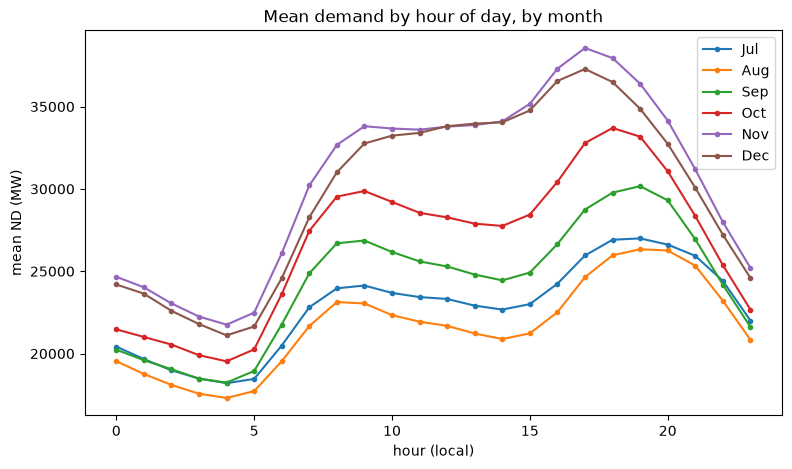

In [18]:
## 9. Are September/October's daily demand profiles flatter (smaller peak-to-trough swing,
## less steep ramp) than the other test months? Uses actual ND directly, no model involved.

test_months = {"Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}

local_hour_all = df.index.tz_convert("Europe/London").hour
local_month_all = df.index.tz_convert("Europe/London").month

fig, ax = plt.subplots(figsize=(9, 5))
for label, month_num in test_months.items():
    mask = local_month_all == month_num
    monthly_profile = df.loc[mask, 'ND'].groupby(local_hour_all[mask]).mean()
    ax.plot(monthly_profile.index, monthly_profile.values, marker='o', markersize=3, label=label)

ax.set_xlabel("hour (local)")
ax.set_ylabel("mean ND (MW)")
ax.set_title("Mean demand by hour of day, by month")
ax.legend()
plt.show()

In [19]:
## 9b. Quantifying the same thing: peak-to-trough amplitude and steepest single-step ramp,
## by month (steepest step = largest |change| between consecutive hourly means)

amplitude_rows = []
for label, month_num in test_months.items():
    mask = local_month_all == month_num
    monthly_profile = df.loc[mask, 'ND'].groupby(local_hour_all[mask]).mean()
    amplitude_rows.append({
        "month": label,
        "min": monthly_profile.min(),
        "max": monthly_profile.max(),
        "peak_to_trough": monthly_profile.max() - monthly_profile.min(),
        "steepest_hour_to_hour_step": monthly_profile.diff().abs().max(),
    })

pd.DataFrame(amplitude_rows)

,month,min,max,peak_to_trough,steepest_hour_to_hour_step
0,Jul,18203.290323,26996.596774,8793.306452,2406.096774
1,Aug,17303.467742,26335.129032,9031.661290,2372.596774
2,Sep,18240.383333,30167.316667,11926.933333,3108.150000
3,Oct,19530.387097,33701.306452,14170.919355,3844.354839
4,Nov,21757.350000,38559.250000,16801.900000,4121.883333
5,Dec,21106.580645,37283.306452,16176.725806,3702.338710


In [20]:
## 9c. "More average" hypothesis, precisely targeted: for each fold, how far is the test
## month's own actual hourly profile from the profile implied by THAT FOLD'S OWN TRAINING
## DATA (not from Jul/Aug specifically, and not from the full year -- from what the linear
## model's period dummies actually saw). Smaller distance => linear model needs less
## correction that month => smaller expected XGBoost advantage, if this hypothesis holds.

profile_distance_rows = []
for f in folds:
    train_mask = (df.index >= f["train_start"]) & (df.index < f["test_start"])
    test_mask = (df.index >= f["test_start"]) & (df.index < f["test_end"])

    train_hour = df.loc[train_mask].index.tz_convert("Europe/London").hour
    test_hour = df.loc[test_mask].index.tz_convert("Europe/London").hour

    train_profile = df.loc[train_mask, 'ND'].groupby(train_hour).mean()
    test_profile = df.loc[test_mask, 'ND'].groupby(test_hour).mean()
    diff = test_profile - train_profile

    profile_distance_rows.append({
        "fold": f["fold"],
        "profile_rmse_vs_training_avg": float(np.sqrt((diff ** 2).mean())),
        "profile_mae_vs_training_avg": float(diff.abs().mean()),
    })

profile_distance_df = pd.DataFrame(profile_distance_rows)
comparison = fold_results_df[["fold", "linear_mae", "xgboost_mae"]].merge(profile_distance_df, on="fold")
comparison["xgboost_advantage"] = comparison["linear_mae"] - comparison["xgboost_mae"]
comparison

,fold,linear_mae,xgboost_mae,profile_rmse_vs_training_avg,profile_mae_vs_training_avg,xgboost_advantage
0,1,289.221869,251.143866,3867.473220,3648.500309,38.078003
1,2,280.513997,262.473839,4421.444776,4230.701145,18.040158
2,3,292.352720,308.963364,1123.117825,1061.274545,-16.610644
3,4,334.450318,332.399611,1843.710981,1482.697324,2.050707
4,5,421.120918,329.496110,5688.977553,5177.526058,91.624808
5,6,426.823371,369.609575,4527.002214,3899.973100,57.213796


In [21]:
## 9d. Correlation between profile distance and XGBoost's advantage, across the 6 folds

comparison[["profile_rmse_vs_training_avg", "profile_mae_vs_training_avg", "xgboost_advantage"]].corr()

,profile_rmse_vs_training_avg,profile_mae_vs_training_avg,xgboost_advantage
profile_rmse_vs_training_avg,1.000000,0.994551,0.910687
profile_mae_vs_training_avg,0.994551,1.000000,0.878237
xgboost_advantage,0.910687,0.878237,1.000000


In [22]:
## 10. Dispatch impact: does the improved forecast improve realized profit against actual
## demand? Uses the 6 walk-forward folds (already whole-day, midnight-aligned test blocks --
## unlike the primary split, no trimming is needed for dispatch). For each fold and each of
## linear / linear+interaction / XGBoost, the dispatch schedule is built from that model's
## FORECAST demand, then repriced against ACTUAL demand via realized_profit -- the same
## forecast-vs-actual distinction already established in dispatch.py / the MIA tools.
## "oracle" (schedule built directly on actual demand) is included as an upper-bound reference.

from energy_forecast.config import BatteryParams
from energy_forecast.dispatch import run_multi_day_dispatch, realized_profit

DISPATCH_PARAMS = BatteryParams()

dispatch_rows = []
for f in folds:
    split_date_f = f["test_start"]
    preds = fold_predictions[f["fold"]]
    actual_f = preds["actual"]

    # Interaction model wasn't fit per fold earlier (section 5 used the primary split only);
    # fit it here per fold, same design as section 5, reusing df_interact/interaction_feature_cols.
    train_df_i_f = df_interact[df_interact.index < split_date_f]
    test_df_i_f = df_interact[df_interact.index >= split_date_f]
    test_mask_f = test_df_i_f.index < f["test_end"]

    interact_model_f = LinearRegression(fit_intercept=True)
    interact_model_f.fit(train_df_i_f[interaction_feature_cols], train_df_i_f['ND'])
    y_fore_interact_f = pd.Series(
        interact_model_f.predict(test_df_i_f.loc[test_mask_f, interaction_feature_cols]),
        index=test_df_i_f.loc[test_mask_f].index,
    )

    forecasts = {
        "linear": preds["linear"],
        "linear_interact": y_fore_interact_f,
        "xgboost": preds["xgboost"],
        "oracle": actual_f,
    }

    for model_name, forecast in forecasts.items():
        schedule = run_multi_day_dispatch(forecast, DISPATCH_PARAMS)
        realized = realized_profit(schedule, actual_f, DISPATCH_PARAMS)
        dispatch_rows.append({
            "fold": f["fold"],
            "model": model_name,
            "forecast_mae": mae(actual_f, forecast),
            "scheduled_profit": float(schedule["profit per period"].sum()),
            "realized_profit": float(realized.sum()),
        })

dispatch_df = pd.DataFrame(dispatch_rows)
dispatch_df

,fold,model,forecast_mae,scheduled_profit,realized_profit
0,1,linear,289.221869,527.423825,541.695158
1,1,linear_interact,223.007721,564.232062,546.733883
2,1,xgboost,251.143866,557.609020,541.485258
3,1,oracle,0.000000,554.359267,554.359267
4,2,linear,280.513997,589.950140,612.330917
5,2,linear_interact,232.197875,631.872064,616.825967
6,2,xgboost,262.473839,616.803528,613.163092
7,2,oracle,0.000000,630.543833,630.543833
8,3,linear,292.352720,852.344625,859.427517
9,3,linear_interact,282.742478,861.633083,858.882992


In [23]:
## 10b. Realized profit by fold and model (pivoted for readability)

dispatch_df.pivot(index="fold", columns="model", values="realized_profit")

model,linear,linear_interact,oracle,xgboost
fold,,,,
1,541.695158,546.733883,554.359267,541.485258
2,612.330917,616.825967,630.543833,613.163092
3,859.427517,858.882992,869.857050,856.267733
4,1056.008550,1059.297842,1068.740767,1057.601883
5,1103.007333,1105.830392,1112.594400,1106.225108
6,1104.979442,1109.308325,1118.068883,1109.365692


In [24]:
## 10c. Does forecast accuracy (MAE) correlate with realized dispatch profit?
## linear / linear_interact / XGBoost rows only (oracle excluded -- MAE=0 by construction,
## would just anchor one end rather than test the relationship among the three real models).

model_rows = dispatch_df[dispatch_df["model"] != "oracle"]
model_rows[["forecast_mae", "realized_profit"]].corr()

,forecast_mae,realized_profit
forecast_mae,1.000000,0.777297
realized_profit,0.777297,1.000000
